# 10 - Vector Space Model: The Algebra of Directions

This notebook is a standalone, executable study path for Chapter 10 of *Geometric Algebra for Computer Science*. The chapter is the hinge between the abstract algebra built in Part I and the richer models that follow. Here the model is deliberately modest: an element of the ordinary Euclidean vector space represents a direction through the origin, and the geometric algebra attached to that vector space supplies products, angles, bivectors, and rotors for those directions.

The useful discipline is to keep asking what is actually being modeled. A vector in this chapter is first a direction, not automatically a free-floating point. A bivector is first an oriented plane element, not automatically a finite patch of material. A rotor is first a direction-preserving orthogonal operator, not a general rigid-body motion. That restraint sounds limiting, but it makes the computations unusually clear. Planar trigonometry, spherical trigonometry, 3-D rotation interpolation, point-group symmetries, and even camera calibration can be expressed as directional bookkeeping with a few carefully chosen metric operations.

The notebook follows the printed chapter rather than the shallow old seed notebooks. It starts with a page audit, then builds numerical and visual checks for the major themes: directions and angular relationships, spherical triangles, rotors and their logarithms, interpolation, crystallographic point groups, noisy rotor estimation, and the camera-calibration example where locations are temporarily treated through the directions by which cameras observe them. All prose and code here are new study material; the textbook headings are used only to verify coverage of the requested printed-page span.

## Printed-page audit

I checked the local PDF before writing the notebook. In this copy, printed p. 247 begins on PDF page 274 and printed p. 270 is PDF page 297, so the requested span is printed pp. 247-270 / PDF pages 274-297. The span starts with the Chapter 10 opener and ends inside the external-camera-calibration programming example. The heading list below is deliberately included because it is the spine of the notebook: every later section is tied to one or more of these headings, but the exposition and examples are original.

| Printed page | PDF page | Heading |
|---:|---:|---|
| 247 | 274 | 10 The Vector Space Model: The Algebra of Directions |
| 248 | 275 | 10.1 The Natural Model for Directions |
| 248 | 275 | 10.2 Angular Relationships |
| 249 | 276 | 10.2.1 The Geometry of Planar Triangles |
| 251 | 278 | 10.2.2 Angular Relationships in 3-D |
| 254 | 281 | 10.2.3 Rotation Groups and Crystallography |
| 256 | 283 | 10.3 Computing with 3-D Rotors |
| 256 | 283 | 10.3.1 Determining a Rotor from a Rotation Plane and an Angle |
| 257 | 284 | 10.3.2 Determining a Rotor from a Frame Rotation in 3-D |
| 258 | 285 | 10.3.3 The Logarithm of a 3-D Rotor |
| 259 | 286 | 10.3.4 Rotation Interpolation |
| 260 | 287 | 10.4 Application: Estimation in the Vector Space Model |
| 260 | 287 | 10.4.1 Noisy Rotor Estimation |
| 260 | 287 | 10.4.2 External Camera Calibration |
| 263 | 290 | 10.5 Convenient Abuse: Locations as Directions |
| 264 | 291 | 10.6 Further Reading |
| 265 | 292 | 10.7 Programming Examples and Exercises |
| 265 | 292 | 10.7.1 Interpolating Rotations |
| 267 | 294 | 10.7.2 Crystallography Implementation |
| 268 | 295 | 10.7.3 External Camera Calibration |

The page span has a compact story. First, the vector-space model is named as the natural algebra for directions. Next, angular relationships are worked out in planar and spherical settings, with crystallography used as a finite-symmetry application. The middle of the chapter turns practical: it constructs 3-D rotors from planes, vector pairs, and frames; extracts rotor logarithms; and interpolates orientations. The final conceptual move is estimation. Noisy data asks for best-fit rotors, and external camera calibration shows how a direction-only observation can still constrain point locations and camera poses when the bookkeeping is explicit.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

PROJECT_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "utils" / "artifacts.py").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.chapter10_vector_space_model import (
    COLORS,
    Rotor3D,
    angle_between,
    camera_calibration_figure,
    crystallography_orbit_figure,
    estimate_depths,
    estimate_rotation_from_directions,
    estimate_translations,
    great_circle_arc,
    interpolate_rotors,
    planar_triangle_metrics,
    point_group_orbit,
    ray_residuals,
    reconstruct_points,
    signed_permutation_group,
    spherical_triangle_metrics,
    synthetic_camera_scene,
)

np.set_printoptions(precision=5, suppress=True)

ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
ARTIFACT_TOPIC = "chapter-10"
CHAPTER_DIR = PROJECT_ROOT / "Geometric-Algebra-for-Computer-Science" / "part-02-models-of-geometry" / "chapter-10-the-vector-space-model-the-algebra-of-directions"
NOTEBOOK_PATH = CHAPTER_DIR / "10-vector-space-model-algebra-of-directions.ipynb"
print(f"project root: {PROJECT_ROOT}")
print(f"artifact root: {ARTIFACT_ROOT}")

project root: D:\Geometry
artifact root: D:\Geometry\artifacts


In [2]:
heading_audit = [
    {'printed_page': 247, 'pdf_page': 274, 'heading': '10 The Vector Space Model: The Algebra of Directions'},
    {'printed_page': 248, 'pdf_page': 275, 'heading': '10.1 The Natural Model for Directions'},
    {'printed_page': 248, 'pdf_page': 275, 'heading': '10.2 Angular Relationships'},
    {'printed_page': 249, 'pdf_page': 276, 'heading': '10.2.1 The Geometry of Planar Triangles'},
    {'printed_page': 251, 'pdf_page': 278, 'heading': '10.2.2 Angular Relationships in 3-D'},
    {'printed_page': 254, 'pdf_page': 281, 'heading': '10.2.3 Rotation Groups and Crystallography'},
    {'printed_page': 256, 'pdf_page': 283, 'heading': '10.3 Computing with 3-D Rotors'},
    {'printed_page': 256, 'pdf_page': 283, 'heading': '10.3.1 Determining a Rotor from a Rotation Plane and an Angle'},
    {'printed_page': 257, 'pdf_page': 284, 'heading': '10.3.2 Determining a Rotor from a Frame Rotation in 3-D'},
    {'printed_page': 258, 'pdf_page': 285, 'heading': '10.3.3 The Logarithm of a 3-D Rotor'},
    {'printed_page': 259, 'pdf_page': 286, 'heading': '10.3.4 Rotation Interpolation'},
    {'printed_page': 260, 'pdf_page': 287, 'heading': '10.4 Application: Estimation in the Vector Space Model'},
    {'printed_page': 260, 'pdf_page': 287, 'heading': '10.4.1 Noisy Rotor Estimation'},
    {'printed_page': 260, 'pdf_page': 287, 'heading': '10.4.2 External Camera Calibration'},
    {'printed_page': 263, 'pdf_page': 290, 'heading': '10.5 Convenient Abuse: Locations as Directions'},
    {'printed_page': 264, 'pdf_page': 291, 'heading': '10.6 Further Reading'},
    {'printed_page': 265, 'pdf_page': 292, 'heading': '10.7 Programming Examples and Exercises'},
    {'printed_page': 265, 'pdf_page': 292, 'heading': '10.7.1 Interpolating Rotations'},
    {'printed_page': 267, 'pdf_page': 294, 'heading': '10.7.2 Crystallography Implementation'},
    {'printed_page': 268, 'pdf_page': 295, 'heading': '10.7.3 External Camera Calibration'}
]

path = save_json(heading_audit, ARTIFACT_TOPIC, 'checks', 'heading-audit.json', root=ARTIFACT_ROOT)
print(f'wrote {path}')
heading_audit[:3], heading_audit[-3:]

wrote D:\Geometry\artifacts\chapter-10\checks\heading-audit.json


([{'printed_page': 247,
   'pdf_page': 274,
   'heading': '10 The Vector Space Model: The Algebra of Directions'},
  {'printed_page': 248,
   'pdf_page': 275,
   'heading': '10.1 The Natural Model for Directions'},
  {'printed_page': 248,
   'pdf_page': 275,
   'heading': '10.2 Angular Relationships'}],
 [{'printed_page': 265,
   'pdf_page': 292,
   'heading': '10.7.1 Interpolating Rotations'},
  {'printed_page': 267,
   'pdf_page': 294,
   'heading': '10.7.2 Crystallography Implementation'},
  {'printed_page': 268,
   'pdf_page': 295,
   'heading': '10.7.3 External Camera Calibration'}])

## Directions before locations

The vector-space model is excellent when the thing being computed is a direction at a common origin. A direction can be scaled to record weight, added to combine influences, wedged with another direction to make an oriented plane element, contracted to measure metric overlap, and divided or multiplied geometrically to express a relative rotation. The model is not trying to describe every Euclidean object at once. It does not make an offset line into a single primitive, and it does not let a translation act structurally on all objects. Those jobs will belong to homogeneous and conformal models later in the book.

This restriction is useful rather than embarrassing. For angular geometry, the objects really are directions. A triangle can be studied through edge vectors. A spherical triangle can be studied through rays from the sphere center. A crystal point group can be generated by orthogonal actions around a fixed point. A camera observation after internal calibration is a ray direction in the camera frame. In all of those settings the vector-space model is not a toy; it is the right instrument.

The products keep the usual scalar trigonometry from becoming detached from geometry. In a plane, the scalar part of a geometric product sees cosines while the bivector part sees oriented sines. In 3-D, the ratio between two unit vectors is not merely an angle number. It is a rotor that contains both the rotation plane and the amount of rotation. When the chapter warns against treating scalar angles as the primary data, this is the reason: the plane and orientation are part of the geometric fact.

The next cell uses an ordinary triangle to make that idea concrete. The code computes side lengths, internal angles, the oriented area represented by a wedge-like signed area, and the residuals in the sine and cosine laws. The vectors are drawn twice: once as a familiar offset triangle and once as pure directions emanating from the origin. Algebraically, the second picture is the model. The first picture is a convenient story we tell our eyes.

{'side_a': 1.697586522095413, 'side_b': 1.7346181135915768, 'side_c': 1.9480503073586164, 'angle_A': 0.951664896785689, 'angle_B': 0.9829698460282481, 'angle_C': 1.2069579107758561, 'area_oriented': 1.37595, 'angle_sum': 3.141592653589793, 'law_of_sines_spread': 5.551115123125783e-17, 'law_of_cosines_error': -8.881784197001252e-16}
wrote D:\Geometry\artifacts\chapter-10\plots\planar-triangle-directions.png
wrote D:\Geometry\artifacts\chapter-10\checks\planar-triangle-metrics.json


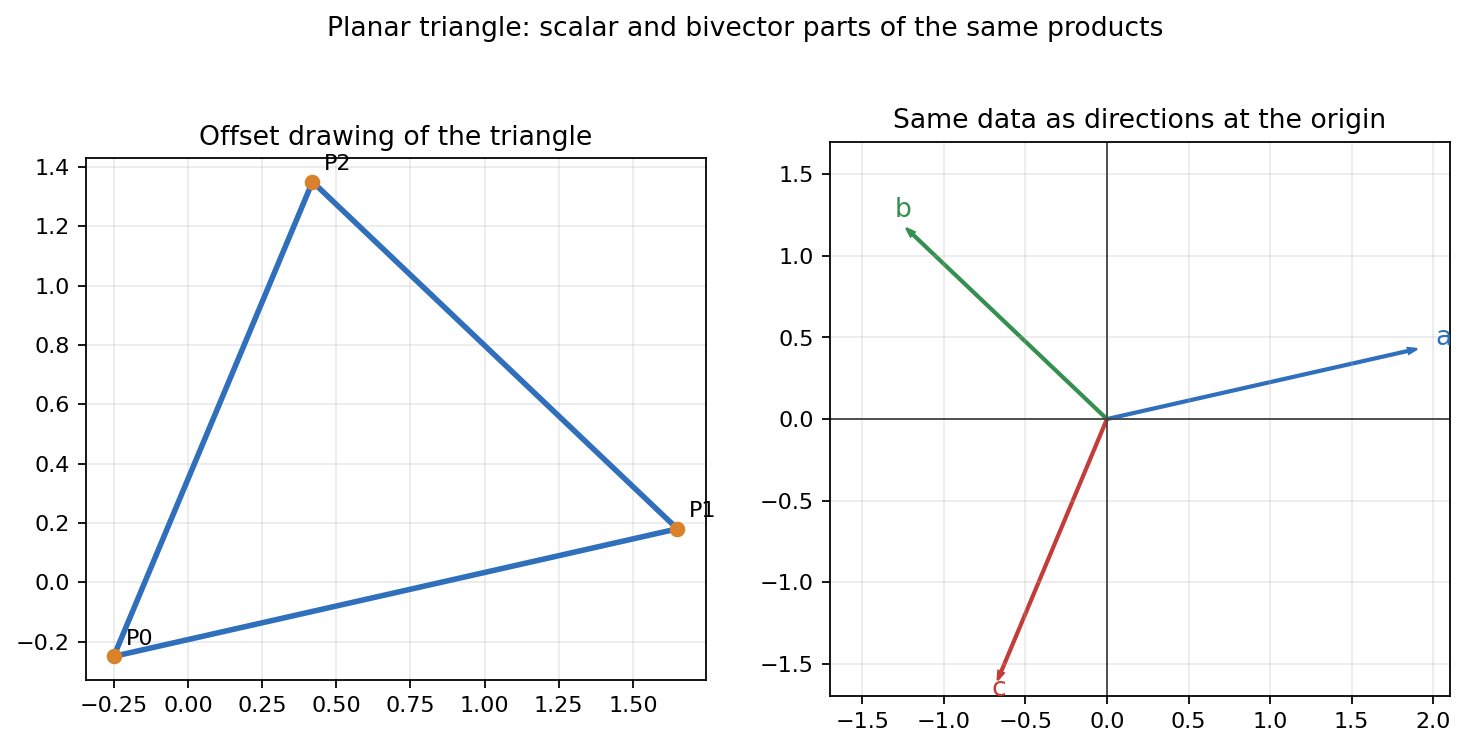

In [3]:
triangle = np.array([
    [-0.25, -0.25],
    [1.65, 0.18],
    [0.42, 1.35],
])
metrics = planar_triangle_metrics(triangle)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]
closed = np.vstack([triangle, triangle[0]])
ax.plot(closed[:, 0], closed[:, 1], color=COLORS['blue'], linewidth=2.5)
ax.scatter(triangle[:, 0], triangle[:, 1], color=COLORS['orange'], zorder=3)
for label, point in zip(['P0', 'P1', 'P2'], triangle, strict=True):
    ax.text(point[0] + 0.04, point[1] + 0.04, label)
ax.set_title('Offset drawing of the triangle')
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)

edge_vectors = [triangle[1] - triangle[0], triangle[2] - triangle[1], triangle[0] - triangle[2]]
ax = axes[1]
for label, vector, color in zip(['a', 'b', 'c'], edge_vectors, [COLORS['blue'], COLORS['green'], COLORS['red']], strict=True):
    ax.arrow(0, 0, vector[0], vector[1], width=0.012, length_includes_head=True, color=color)
    ax.text(1.06 * vector[0], 1.06 * vector[1], label, color=color, fontsize=12)
ax.axhline(0, color='0.25', linewidth=0.8)
ax.axvline(0, color='0.25', linewidth=0.8)
ax.set_title('Same data as directions at the origin')
ax.set_aspect('equal')
ax.grid(True, alpha=0.25)
ax.set_xlim(-1.7, 2.1)
ax.set_ylim(-1.7, 1.7)
fig.suptitle('Planar triangle: scalar and bivector parts of the same products', y=1.02)

plot_path = save_matplotlib(fig, ARTIFACT_TOPIC, 'plots', 'planar-triangle-directions.png', root=ARTIFACT_ROOT)
plt.close(fig)
summary_path = save_json(metrics, ARTIFACT_TOPIC, 'checks', 'planar-triangle-metrics.json', root=ARTIFACT_ROOT)
print(metrics)
print(f'wrote {plot_path}')
print(f'wrote {summary_path}')
display_artifact(plot_path, width=900)

## Angular relationships on the sphere

A spherical triangle is still a triangle of directions. Its vertices are unit vectors from the sphere center, its sides are angles between those vectors, and its internal angles are angles between tangent directions or, equivalently, between the planes that contain the great-circle sides. This is exactly the kind of problem where the vector-space model earns its keep: the physical drawing lives on a curved surface, but the computations use linear directions, bivectors, and rotors in the 3-D algebra.

The spherical case also shows why it is often better to keep geometric quantities together instead of immediately reducing them to scalar formulas. A side length is an angle between two rays, but the directed plane of that side matters whenever we compose rotations around the sphere. The laws of spherical trigonometry can be recovered by splitting products into grade parts, but the rotor products know more than the scalar laws alone. They retain the orientation of the great-circle planes.

In the code below, the three vertices are not chosen as a right octant, because a generic triangle is better for testing. The helper computes side lengths, internal angles, spherical excess, and two cosine-law residuals. The figure draws a translucent sphere, the three geodesic arcs, and the radial directions to the vertices. The important checks are the residuals: if the triangle has been assembled consistently, the side and angle versions of the spherical cosine law agree to numerical precision.

The excess value is also meaningful. On a unit sphere, spherical excess equals the area of the spherical triangle. That is a delightful example of the vector-space model doing curved geometry without pretending that the point on the sphere is itself a new algebraic primitive. The point is observed and computed through its direction from the origin.

{'side_a': 1.5553016439120344, 'side_b': 0.9876024261559933, 'side_c': 1.341329528749152, 'angle_A': 1.7062516712629736, 'angle_B': 0.9740374850955357, 'angle_C': 1.3053812302639423, 'spherical_excess': 0.8440777330326585, 'side_cosine_error': 1.214306433183765e-17, 'angle_cosine_error': 2.7755575615628914e-17}
wrote D:\Geometry\artifacts\chapter-10\plots\spherical-triangle.png
wrote D:\Geometry\artifacts\chapter-10\checks\spherical-triangle-metrics.json


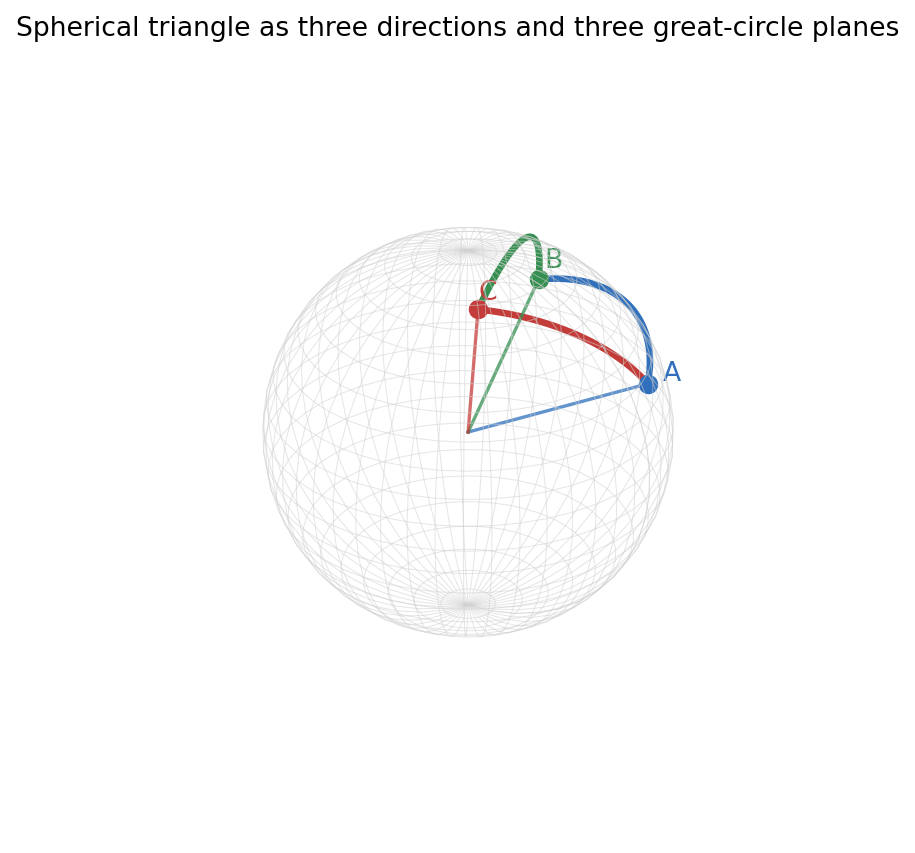

In [4]:
sphere_vertices = np.vstack([
    [0.88, 0.18, 0.43],
    [-0.12, 0.91, 0.39],
    [0.25, -0.34, 0.91],
])
sphere_vertices = np.vstack([v / np.linalg.norm(v) for v in sphere_vertices])
spherical = spherical_triangle_metrics(*sphere_vertices)

fig = plt.figure(figsize=(7.2, 6.4))
ax = fig.add_subplot(111, projection='3d')
u = np.linspace(0, 2 * np.pi, 48)
v = np.linspace(0, np.pi, 24)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(xs, ys, zs, color='0.82', linewidth=0.45, alpha=0.55)
colors = [COLORS['blue'], COLORS['green'], COLORS['red']]
for start_v, end_v, color in [
    (sphere_vertices[0], sphere_vertices[1], colors[0]),
    (sphere_vertices[1], sphere_vertices[2], colors[1]),
    (sphere_vertices[2], sphere_vertices[0], colors[2]),
]:
    arc = great_circle_arc(start_v, end_v)
    ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color=color, linewidth=3)
for label, vertex, color in zip(['A', 'B', 'C'], sphere_vertices, colors, strict=True):
    ax.plot([0, vertex[0]], [0, vertex[1]], [0, vertex[2]], color=color, linewidth=1.5, alpha=0.75)
    ax.scatter([vertex[0]], [vertex[1]], [vertex[2]], color=color, s=60)
    ax.text(*(1.08 * vertex), label, color=color, fontsize=12)
ax.set_title('Spherical triangle as three directions and three great-circle planes')
ax.set_box_aspect((1, 1, 1))
ax.set_axis_off()

plot_path = save_matplotlib(fig, ARTIFACT_TOPIC, 'plots', 'spherical-triangle.png', root=ARTIFACT_ROOT)
plt.close(fig)
summary_path = save_json(spherical, ARTIFACT_TOPIC, 'checks', 'spherical-triangle-metrics.json', root=ARTIFACT_ROOT)
print(spherical)
print(f'wrote {plot_path}')
print(f'wrote {summary_path}')
display_artifact(plot_path, width=720)

## Rotors, logarithms, and interpolation

In 3-D Euclidean space every bivector is dual to an axis vector, so the notebook uses a unit quaternion as the numerical carrier for a rotor and an axis-angle vector as the numerical carrier for the dual bivector logarithm. That is only a representation choice. The geometric idea is the same one used in the chapter: the rotor is the exponential of a bivector half-angle, and the logarithm recovers the directed plane and amount of rotation needed for interpolation or estimation.

There are three practical construction patterns worth keeping separate. If we know the rotation plane and angle, we can write the rotor immediately. If we know one unit vector and its desired image, we can construct the smallest rotor in their common plane; that is underdetermined only when the vectors are opposite. If we know a full frame and its image, or many noisy direction correspondences, we can solve for a best-fit rotor. All three show up in graphics, robotics, and vision.

Interpolation is where the logarithm becomes operational. Given initial and final rotors, compute the relative rotor, scale its logarithm, exponentiate, and apply the partial rotor to the initial orientation. This keeps the path on the rotation group instead of interpolating matrix entries or Euler angles. The result is the familiar shortest-branch spherical interpolation, but expressed as rotor arithmetic rather than as a special-purpose formula.

The next cell records a small vector-to-vector rotor and its logarithm, then the following cell draws a complete interpolation path for a body frame. Notice that the sampled frames do not shear or shrink. Every intermediate state is still a rotor action, so lengths and right angles are preserved by construction.

In [5]:
source = np.array([1.0, 0.2, -0.1])
target = np.array([-0.25, 0.9, 0.36])
turn = Rotor3D.from_two_vectors(source, target)
rotated_source = turn.rotate(source / np.linalg.norm(source))
rotor_summary = {
    'source_unit': (source / np.linalg.norm(source)).round(6).tolist(),
    'target_unit': (target / np.linalg.norm(target)).round(6).tolist(),
    'rotor_quaternion_wxyz': turn.q.round(6).tolist(),
    'log_axis_angle_vector': turn.log_vector().round(6).tolist(),
    'rotation_angle_degrees': float(np.degrees(np.linalg.norm(turn.log_vector()))),
    'mapping_error': float(np.linalg.norm(rotated_source - target / np.linalg.norm(target))),
}
assert rotor_summary['mapping_error'] < 1e-10
path = save_json(rotor_summary, ARTIFACT_TOPIC, 'checks', 'vector-to-vector-rotor.json', root=ARTIFACT_ROOT)
print(rotor_summary)
print(f'wrote {path}')

{'source_unit': [0.9759, 0.19518, -0.09759], 'target_unit': [-0.249738, 0.899056, 0.359623], 'rotor_quaternion_wxyz': [0.669576, 0.117933, -0.243874, 0.691582], 'log_axis_angle_vector': [0.265848, -0.549748, 1.558988], 'rotation_angle_degrees': 95.93136020432017, 'mapping_error': 7.850462293418876e-17}
wrote D:\Geometry\artifacts\chapter-10\checks\vector-to-vector-rotor.json


{'samples': 9, 'relative_log_norm_degrees': 126.2721582172959, 'endpoint_start_error': 0.0, 'endpoint_finish_error': 5.324442579404919e-16, 'determinants': [0.9999999999999999, 1.0000000000000002, 1.0, 1.0, 1.0000000000000002, 1.0, 1.0, 0.9999999999999999, 1.0]}
wrote D:\Geometry\artifacts\chapter-10\plots\rotor-interpolation-frames.png
wrote D:\Geometry\artifacts\chapter-10\checks\rotor-interpolation-summary.json


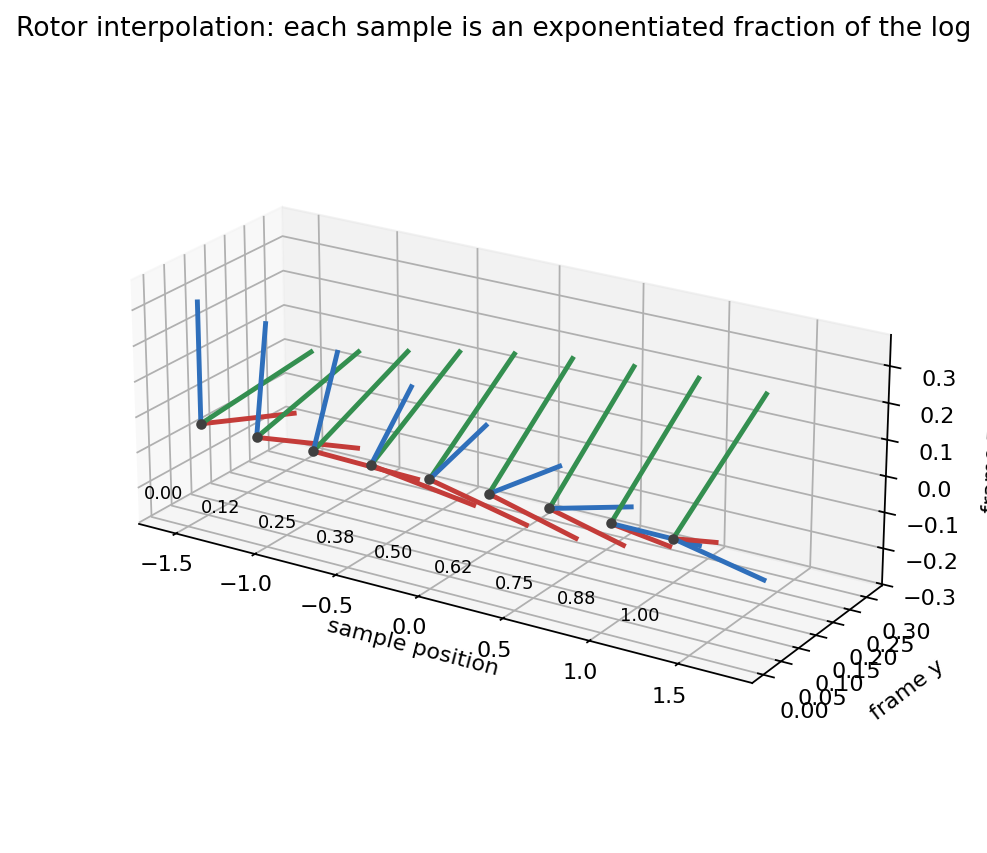

In [6]:
start = Rotor3D.from_axis_angle([0, 0, 1], np.deg2rad(18))
finish = Rotor3D.from_axis_angle([0.25, 0.9, 0.35], np.deg2rad(132))
amounts = np.linspace(0.0, 1.0, 9)
rotors = [interpolate_rotors(start, finish, amount) for amount in amounts]

fig = plt.figure(figsize=(8.2, 6.4))
ax = fig.add_subplot(111, projection='3d')
origin_offsets = np.column_stack([np.linspace(-1.4, 1.4, len(rotors)), np.zeros(len(rotors)), np.zeros(len(rotors))])
local_axes = np.eye(3)
axis_colors = [COLORS['red'], COLORS['green'], COLORS['blue']]
for offset, rotor, amount in zip(origin_offsets, rotors, amounts, strict=True):
    for axis, color in zip(local_axes, axis_colors, strict=True):
        end = offset + 0.34 * rotor.rotate(axis)
        ax.plot([offset[0], end[0]], [offset[1], end[1]], [offset[2], end[2]], color=color, linewidth=2.2)
    ax.scatter([offset[0]], [offset[1]], [offset[2]], color='0.25', s=14)
    ax.text(offset[0], offset[1] - 0.14, offset[2] - 0.12, f'{amount:.2f}', fontsize=8)
ax.set_title('Rotor interpolation: each sample is an exponentiated fraction of the log')
ax.set_xlabel('sample position')
ax.set_ylabel('frame y')
ax.set_zlabel('frame z')
ax.set_box_aspect((2.7, 1, 1))
ax.view_init(elev=22, azim=-58)

interp_summary = {
    'samples': len(rotors),
    'relative_log_norm_degrees': float(np.degrees(np.linalg.norm((finish * start.inverse()).log_vector()))),
    'endpoint_start_error': float(np.linalg.norm(rotors[0].as_matrix() - start.as_matrix())),
    'endpoint_finish_error': float(np.linalg.norm(rotors[-1].as_matrix() - finish.as_matrix())),
    'determinants': [float(np.linalg.det(rotor.as_matrix())) for rotor in rotors],
}
assert interp_summary['endpoint_start_error'] < 1e-10
assert interp_summary['endpoint_finish_error'] < 1e-10
assert max(abs(det - 1.0) for det in interp_summary['determinants']) < 1e-10
plot_path = save_matplotlib(fig, ARTIFACT_TOPIC, 'plots', 'rotor-interpolation-frames.png', root=ARTIFACT_ROOT)
plt.close(fig)
summary_path = save_json(interp_summary, ARTIFACT_TOPIC, 'checks', 'rotor-interpolation-summary.json', root=ARTIFACT_ROOT)
print(interp_summary)
print(f'wrote {plot_path}')
print(f'wrote {summary_path}')
display_artifact(plot_path, width=820)

## Crystallography as finite directional symmetry

A point group is a finite set of orthogonal operations around a fixed point. In geometric algebra those operations are versors: reflection vectors and their products, with rotations arising from even products. The vector-space model is therefore a natural home for the local part of crystallography. It can classify and apply the directional symmetries around an atom or motif. It does not yet handle lattice translations as the same kind of rotor-like operation; that extra uniformity arrives later with richer models.

The code uses the cubic rotational point group as a concrete, checkable example. The group consists of the 24 proper signed permutation matrices, which are exactly the orientation-preserving symmetries of a cube. Applying them to one generic seed direction produces 24 distinct orbit points. If mirror operations are included, the full signed permutation group has 48 elements. This mirrors the chapter's point that finite combinations of vector-space orthogonal operations can generate all equivalent local directions in a crystal point group.

Although the implementation below uses matrices for convenience, the action is the same action a rotor or versor would perform by sandwiching. The geometric habit is the important part: store the symmetry as an operator, apply it uniformly to directions, and check closure by multiplying operators rather than by manually listing every orbit point.

In [7]:
orbit = point_group_orbit([0.91, 0.37, 0.22], proper_only=True)
full_group_count = len(signed_permutation_group(proper_only=False))
proper_group_count = len(signed_permutation_group(proper_only=True))
unique_orbit_count = len(np.unique(np.round(orbit, 10), axis=0))
fig = crystallography_orbit_figure(orbit)
html_path = save_plotly_html(fig, ARTIFACT_TOPIC, 'plots', 'cubic-point-group-orbit.html', root=ARTIFACT_ROOT)
crystal_summary = {
    'proper_cubic_group_count': proper_group_count,
    'full_signed_permutation_group_count': full_group_count,
    'unique_orbit_count': int(unique_orbit_count),
    'orbit_radius_spread': float(np.ptp(np.linalg.norm(orbit, axis=1))),
}
assert proper_group_count == 24
assert full_group_count == 48
assert unique_orbit_count == 24
assert crystal_summary['orbit_radius_spread'] < 1e-10
summary_path = save_json(crystal_summary, ARTIFACT_TOPIC, 'checks', 'crystallography-point-group.json', root=ARTIFACT_ROOT)
print(crystal_summary)
print(f'wrote {html_path}')
print(f'wrote {summary_path}')
display_artifact(html_path, width='100%', height=620)

{'proper_cubic_group_count': 24, 'full_signed_permutation_group_count': 48, 'unique_orbit_count': 24, 'orbit_radius_spread': 0.0}
wrote D:\Geometry\artifacts\chapter-10\plots\cubic-point-group-orbit.html
wrote D:\Geometry\artifacts\chapter-10\checks\crystallography-point-group.json


## Estimation and camera calibration

The chapter's final technical movement is from exact construction to estimation. In real computer vision or robotics data, a measured direction is not exact, and a rotor cannot be trusted merely because three noisy correspondences happen to define a frame. A better strategy is to solve a least-squares problem: find the rotor that moves one set of directions as close as possible to another. Numerically this is the same family of problem as Wahba or Kabsch alignment. Geometrically it is still a rotor-estimation problem in the vector-space model.

External camera calibration then adds a second layer. After internal calibration, an image point is a spatial ray direction in the camera coordinate frame. The camera does not know the depth along that ray. If several synchronized cameras observe the same moving marker, the unknown depths, camera translations, camera rotations, and world marker positions constrain each other. The formulas in the chapter alternate between partial optima: estimate translations when rotations, scales, and points are fixed; estimate depths by projection onto the ray; estimate world points by averaging or least squares; estimate rotations by a best-fit rotor; iterate.

This is also the chapter's most useful warning about abusing the vector-space model. Camera centers and reconstructed marker locations are locations, not pure directions. We can temporarily use vectors for them because the problem is made of point objects and ray directions, and because the notebook keeps the roles separate in names and functions. That is effective engineering, but it is bookkeeping by convention. Once lines, planes, translations, and incidence among offset objects become central, the later homogeneous and conformal models provide structural representations that reduce this manual burden.

The next two cells demonstrate the estimation theme. First, noisy directions are aligned by a best-fit rotor. Second, a synthetic camera rig observes a marker path; the rays triangulate the points, recover per-ray depths, update translations by the chapter-style averaging formula, and save an interactive 3-D scene.

In [8]:
rng = np.random.default_rng(42)
source_dirs = np.vstack([rng.normal(size=3) for _ in range(18)])
source_dirs = np.vstack([v / np.linalg.norm(v) for v in source_dirs])
true_rotor = Rotor3D.from_axis_angle([0.2, -0.45, 0.87], np.deg2rad(41.0))
target_clean = np.vstack([true_rotor.rotate(v) for v in source_dirs])
target_noisy = np.vstack([v + rng.normal(scale=0.015, size=3) for v in target_clean])
target_noisy = np.vstack([v / np.linalg.norm(v) for v in target_noisy])
estimated_rotor, singular_values, rms = estimate_rotation_from_directions(source_dirs, target_noisy)
rotation_error = (estimated_rotor * true_rotor.inverse()).log_vector()
estimation_summary = {
    'direction_pairs': int(source_dirs.shape[0]),
    'singular_values': singular_values.round(6).tolist(),
    'rms_direction_error': rms,
    'rotation_error_degrees': float(np.degrees(np.linalg.norm(rotation_error))),
    'estimated_rotor': estimated_rotor.q.round(6).tolist(),
}
assert estimation_summary['rotation_error_degrees'] < 2.0
path = save_json(estimation_summary, ARTIFACT_TOPIC, 'checks', 'noisy-rotor-estimation.json', root=ARTIFACT_ROOT)
print(estimation_summary)
print(f'wrote {path}')

{'direction_pairs': 18, 'singular_values': [9.297949, 5.674739, 3.025378], 'rms_direction_error': 0.014661030439445636, 'rotation_error_degrees': 0.22347225202510781, 'estimated_rotor': [0.936397, 0.069375, -0.156653, 0.306282]}
wrote D:\Geometry\artifacts\chapter-10\checks\noisy-rotor-estimation.json


In [9]:
cameras, true_points, observations = synthetic_camera_scene(noise=0.004, seed=4)
reconstructed = reconstruct_points(cameras, observations)
residuals = ray_residuals(cameras, observations, reconstructed)
depths = estimate_depths(cameras, observations, reconstructed)
translation_update = estimate_translations([camera.rotation for camera in cameras], observations, depths, reconstructed)
true_centers = np.vstack([camera.center for camera in cameras])
translation_error = np.linalg.norm(translation_update - true_centers, axis=1)
fig = camera_calibration_figure(cameras, true_points, reconstructed, observations)
html_path = save_plotly_html(fig, ARTIFACT_TOPIC, 'plots', 'external-camera-calibration.html', root=ARTIFACT_ROOT)
calibration_summary = {
    'camera_count': len(cameras),
    'point_count': int(true_points.shape[0]),
    'rms_reconstruction_error': float(np.sqrt(np.mean(np.linalg.norm(reconstructed - true_points, axis=1) ** 2))),
    'rms_ray_residual': float(np.sqrt(np.mean(residuals ** 2))),
    'mean_depth': float(np.mean(depths)),
    'translation_update_errors': translation_error.round(6).tolist(),
}
assert calibration_summary['rms_reconstruction_error'] < 0.05
assert calibration_summary['rms_ray_residual'] < 0.02
summary_path = save_json(calibration_summary, ARTIFACT_TOPIC, 'checks', 'external-camera-calibration.json', root=ARTIFACT_ROOT)
print(calibration_summary)
print(f'wrote {html_path}')
print(f'wrote {summary_path}')
display_artifact(html_path, width='100%', height=650)

{'camera_count': 3, 'point_count': 18, 'rms_reconstruction_error': 0.01582016126618658, 'rms_ray_residual': 0.012770459463164475, 'mean_depth': 3.1487521655142356, 'translation_update_errors': [0.005641, 0.002163, 0.004091]}
wrote D:\Geometry\artifacts\chapter-10\plots\external-camera-calibration.html
wrote D:\Geometry\artifacts\chapter-10\checks\external-camera-calibration.json


## What to carry forward

The vector-space model is not a lesser version of the later models. It is the exact model for algebraic work with directions. If a problem can be reduced to directions at one origin, the model is often the cleanest available choice. It gives oriented areas, angles between vectors and planes, rotor composition, interpolation by logarithms, and finite local symmetry groups without adding representational overhead.

The cost is that location is not structural. A point can be represented by a position vector, but the model itself does not know whether that vector is being used as a direction, a point, a velocity, a camera center, or a displacement. The notebook's camera example works because each array is named and updated according to its role. That kind of discipline is adequate for point-and-ray calibration, planetary orbits around a chosen origin, and many graphics tasks. It becomes fragile when code needs to treat offset lines, planes, circles, spheres, translations, and rotations with uniform operations.

The important habit is therefore not to memorize a boundary between models, but to ask what the computation wants preserved. If it wants angular relationships, relative orientation, and fixed-point symmetry, the vector-space model is the natural language. If it wants incidence and translation of offset objects, it is time to move to a model that represents those objects structurally. Chapter 10 is valuable because it teaches both lessons at once: it shows how far ordinary directions can go, and it exposes exactly where bookkeeping starts to ask for a richer algebra.

In [10]:
import nbformat

nb = nbformat.read(NOTEBOOK_PATH, as_version=4)
markdown_words = sum(
    len(''.join(cell.get('source', '')).split())
    for cell in nb.cells
    if cell.cell_type == 'markdown'
)
code_cells = sum(1 for cell in nb.cells if cell.cell_type == 'code')
artifact_files = sorted((ARTIFACT_ROOT / ARTIFACT_TOPIC).rglob('*'))
artifact_files = [path for path in artifact_files if path.is_file()]
sanity_path = ARTIFACT_ROOT / ARTIFACT_TOPIC / 'checks' / 'sanity-checks.json'
if sanity_path not in artifact_files:
    artifact_files.append(sanity_path)
artifact_files = sorted(artifact_files)
checks = {
    'notebook': str(NOTEBOOK_PATH),
    'markdown_words': int(markdown_words),
    'code_cells': int(code_cells),
    'artifact_count': len(artifact_files),
    'artifact_files': [str(path.relative_to(PROJECT_ROOT)) for path in artifact_files],
    'page_span': {'printed': '247-270', 'pdf': '274-297'},
    'planar_law_of_sines_spread': metrics['law_of_sines_spread'],
    'spherical_side_cosine_error': spherical['side_cosine_error'],
    'spherical_angle_cosine_error': spherical['angle_cosine_error'],
    'rotor_interpolation_endpoint_error': interp_summary['endpoint_finish_error'],
    'crystal_unique_orbit_count': crystal_summary['unique_orbit_count'],
    'camera_rms_reconstruction_error': calibration_summary['rms_reconstruction_error'],
}
assert markdown_words >= 2000
assert code_cells >= 8
assert len(artifact_files) >= 6
assert abs(metrics['law_of_cosines_error']) < 1e-10
assert metrics['law_of_sines_spread'] < 1e-10
assert abs(spherical['side_cosine_error']) < 1e-10
assert abs(spherical['angle_cosine_error']) < 1e-10
assert interp_summary['endpoint_finish_error'] < 1e-10
assert crystal_summary['unique_orbit_count'] == 24
assert calibration_summary['rms_reconstruction_error'] < 0.05
path = save_json(checks, ARTIFACT_TOPIC, 'checks', 'sanity-checks.json', root=ARTIFACT_ROOT)
print(checks)
print(f'wrote {path}')

{'notebook': 'D:\\Geometry\\Geometric-Algebra-for-Computer-Science\\part-02-models-of-geometry\\chapter-10-the-vector-space-model-the-algebra-of-directions\\10-vector-space-model-algebra-of-directions.ipynb', 'markdown_words': 2422, 'code_cells': 10, 'artifact_count': 14, 'artifact_files': ['artifacts\\chapter-10\\checks\\crystallography-point-group.json', 'artifacts\\chapter-10\\checks\\external-camera-calibration.json', 'artifacts\\chapter-10\\checks\\heading-audit.json', 'artifacts\\chapter-10\\checks\\noisy-rotor-estimation.json', 'artifacts\\chapter-10\\checks\\planar-triangle-metrics.json', 'artifacts\\chapter-10\\checks\\rotor-interpolation-summary.json', 'artifacts\\chapter-10\\checks\\sanity-checks.json', 'artifacts\\chapter-10\\checks\\spherical-triangle-metrics.json', 'artifacts\\chapter-10\\checks\\vector-to-vector-rotor.json', 'artifacts\\chapter-10\\plots\\cubic-point-group-orbit.html', 'artifacts\\chapter-10\\plots\\external-camera-calibration.html', 'artifacts\\chapter-